In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data.csv')

In [6]:
print("Размерность данных", df.shape)

Размерность данных (12330, 18)


In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [10]:
print("\nСтолбцы:", df.columns.tolist())


Столбцы: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [14]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [16]:
print("Доля покупок по типу дня и категории покупателя:\n")

pivot = pd.pivot_table(
    df,
    values='Revenue',
    index=['Weekend'],
    columns=['VisitorType'],
    aggfunc='mean',
    fill_value=0
)

pivot.round(4)

Доля покупок по типу дня и категории покупателя:



VisitorType,New_Visitor,Other,Returning_Visitor
Weekend,,,
False,0.2609,0.1923,0.1318
True,0.2192,0.1429,0.1650


# Условные вероятности

### ***Задача:*** найти вероятности совершения покупки в зависимости от типа покупателя / месяца посещения магазина / типа дня

In [35]:
# Функция для нахождения условных вероятностей
def conditional_probability(df, condition_col, condition_val, target_col, target_val=1):
    subset = df[df[condition_col]==condition_val]
    if len(subset)==0:
        return 0
    return (subset[target_col]==target_val).mean()
    

In [37]:
print("УСЛОВНЫЕ ВЕРОЯТНОСТИ ПОКУПКИ:")

print("\nПо типу покупателя:")
for visitor_type in df['VisitorType'].unique():
    prob = conditional_probability(df, 'VisitorType', visitor_type, 'Revenue')
    print(f" P(Revenue | VisitorType={visitor_type}) = {prob:.4f}")

print("\nПо Месяцу посещения:")
for month in df['Month'].unique():
    prob = conditional_probability(df, 'Month', month, 'Revenue')
    print(f" P(Revenue | Month={month}) = {prob:.4f}")

print("\nПо типу дня:")
for weekend in df['Weekend'].unique():
    prob = conditional_probability(df, 'Weekend', weekend, 'Revenue')
    print(f" P(Revenue | Weekend={weekend}) = {prob:.4f}")

УСЛОВНЫЕ ВЕРОЯТНОСТИ ПОКУПКИ:

По типу покупателя:
 P(Revenue | VisitorType=Returning_Visitor) = 0.1393
 P(Revenue | VisitorType=New_Visitor) = 0.2491
 P(Revenue | VisitorType=Other) = 0.1882

По Месяцу посещения:
 P(Revenue | Month=Feb) = 0.0163
 P(Revenue | Month=Mar) = 0.1007
 P(Revenue | Month=May) = 0.1085
 P(Revenue | Month=Oct) = 0.2095
 P(Revenue | Month=June) = 0.1007
 P(Revenue | Month=Jul) = 0.1528
 P(Revenue | Month=Aug) = 0.1755
 P(Revenue | Month=Nov) = 0.2535
 P(Revenue | Month=Sep) = 0.1920
 P(Revenue | Month=Dec) = 0.1251

По типу дня:
 P(Revenue | Weekend=False) = 0.1489
 P(Revenue | Weekend=True) = 0.1740


# Формула полной вероятности

## ***Задача:*** известна вероятность покупки для каждого типа посетителей. Найти общую вероятность покупки.

In [43]:
print("ФОРМУЛА ПОЛНОЙ ВЕРОЯТНОСТИ:")
print("P(Revenue = TRUE) = Σ P(Revenue = TRUE | VisitorType = i) * P(VisitorType = i)")
print("=" * 80)

total_prob = 0.0
prob_details = []
 
for visitor_type in sorted(df['VisitorType'].unique()):
    p_visitor = (df['VisitorType'] == visitor_type).mean()

    p_revenue_given_visitor = conditional_probability(df, 'VisitorType', visitor_type, 'Revenue')

    contribution = p_revenue_given_visitor * p_visitor
    total_prob += contribution

    prob_details.append({
        'VisitorType': visitor_type,
        'P(VisitorType)': p_visitor,
        'P(Revenue|VisitorType)': p_revenue_given_visitor,
        'Вклад': contribution
    })

# Создаем DataFrame для наглядности
prob_df = pd.DataFrame(prob_details)

print(f"\nОбщая вероятность покупки, рассчитанная по формуле полной вероятности: {total_prob:.4f}")
print(f"Общая вероятность покупки, рассчитанная напрямую из данных: {df['Revenue'].mean():.4f}")

prob_df.round(4)

ФОРМУЛА ПОЛНОЙ ВЕРОЯТНОСТИ:
P(Revenue = TRUE) = Σ P(Revenue = TRUE | VisitorType = i) * P(VisitorType = i)

Общая вероятность покупки, рассчитанная по формуле полной вероятности: 0.1547
Общая вероятность покупки, рассчитанная напрямую из данных: 0.1547


,VisitorType,P(VisitorType),P(Revenue|VisitorType),Вклад
0,New_Visitor,0.1374,0.2491,0.0342
1,Other,0.0069,0.1882,0.0013
2,Returning_Visitor,0.8557,0.1393,0.1192


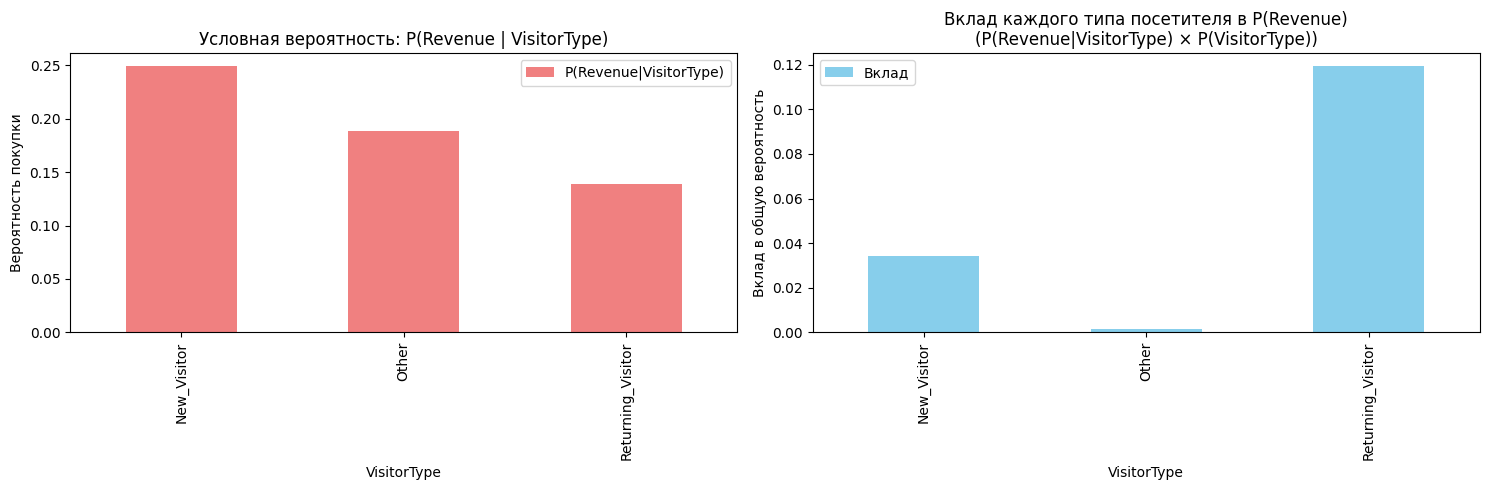

In [117]:
# --- Визуализация вкладов ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Левая часть: Условная вероятность P(Revenue | VisitorType)
prob_df.plot(x='VisitorType', y='P(Revenue|VisitorType)', kind='bar', ax=ax1, color='lightcoral')
ax1.set_title('Условная вероятность: P(Revenue | VisitorType)')
ax1.set_ylabel('Вероятность покупки')
ax1.set_xlabel('VisitorType')
# Правая часть: Вклад каждого типа посетителя в общую вероятность
prob_df.plot(x='VisitorType', y='Вклад', kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Вклад каждого типа посетителя в P(Revenue)\n(P(Revenue|VisitorType) × P(VisitorType))')
ax2.set_ylabel('Вклад в общую вероятность')
ax2.set_xlabel('VisitorType')

plt.tight_layout()
plt.show()

# Формула Байеса

## ***Задача:*** мы видим новый заказ и хотим узнать, к какому типу, скорее всего, относится покупатель

In [58]:
print("ТЕОРЕМА БАЙЕСА:")
print("P(VisitorType | Revenue = TRUE) = [P(Revenue = TRUE | VisitorType) * P(VisitorType)] / P(Revenue = TRUE)")
print("=" * 80)

# Знаменатель: P(Revenue = TRUE)
P_Revenue = df['Revenue'].mean()

bayes_results = []

# Перебираем все уникальные значения TrafficType
for visitor_type in sorted(df['VisitorType'].unique()):
    # P(TrafficType = i) - априорная вероятность
    P_visitor = (df['VisitorType'] == visitor_type).mean()

    # P(Revenue = TRUE | TrafficType = i) - правдоподобие
    P_revenue_given_visitor = conditional_probability(df, 'VisitorType', visitor_type, 'Revenue')

    # Применяем теорему Байеса
    P_visitor_given_revenue = (P_revenue_given_visitor * P_visitor) / P_Revenue

    bayes_results.append({
        'VisitorType': visitor_type,
        'P(VisitorType)': P_visitor,
        'P(Revenue|VisitorType)': P_revenue_given_visitor,
        'P(VisitorType|Revenue)': P_visitor_given_revenue
    })

# Создаем DataFrame для наглядности
bayes_df = pd.DataFrame(bayes_results)
print("Результаты применения теоремы Байеса:")
bayes_df.round(4)

ТЕОРЕМА БАЙЕСА:
P(VisitorType | Revenue = TRUE) = [P(Revenue = TRUE | VisitorType) * P(VisitorType)] / P(Revenue = TRUE)
Результаты применения теоремы Байеса:


,VisitorType,P(VisitorType),P(Revenue|VisitorType),P(VisitorType|Revenue)
0,New_Visitor,0.1374,0.2491,0.2212
1,Other,0.0069,0.1882,0.0084
2,Returning_Visitor,0.8557,0.1393,0.7704


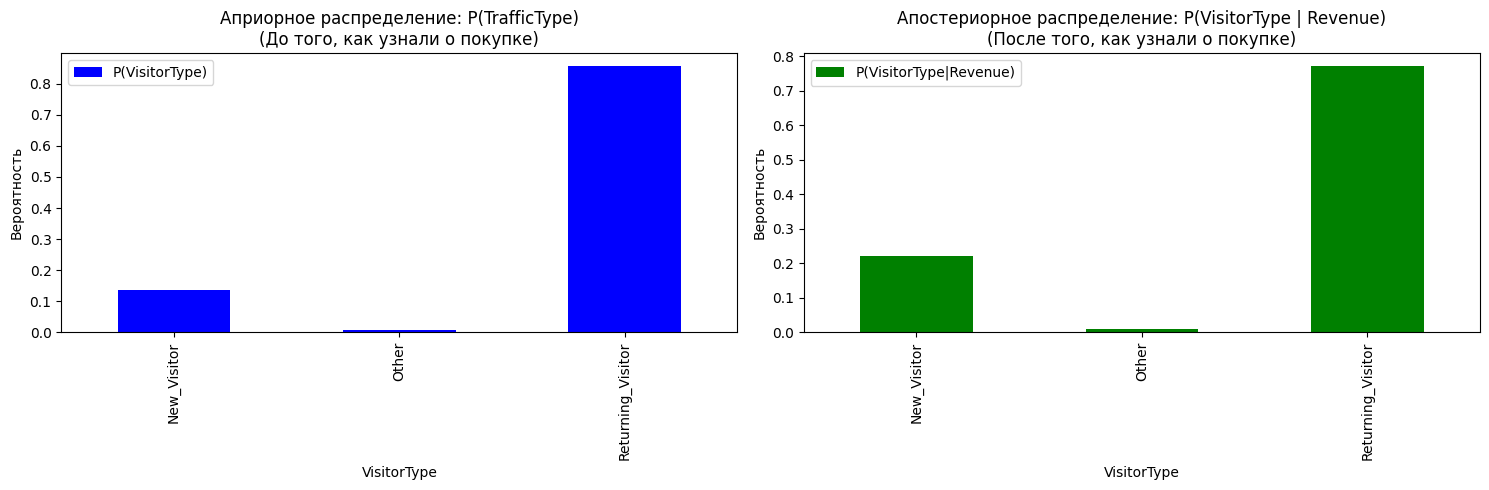

In [60]:
# --- Визуализация априорного и апостериорного распределений ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Левая часть: Априорное распределение P(VisitorType)
bayes_df.plot(x='VisitorType', y='P(VisitorType)', kind='bar', ax=ax1, color='blue')
ax1.set_title('Априорное распределение: P(TrafficType)\n(До того, как узнали о покупке)')
ax1.set_ylabel('Вероятность')
ax1.set_xlabel('VisitorType')

# Правая часть: Апостериорное распределение P(VisitorType | Revenue)
bayes_df.plot(x='VisitorType', y='P(VisitorType|Revenue)', kind='bar', ax=ax2, color='green')
ax2.set_title('Апостериорное распределение: P(VisitorType | Revenue)\n(После того, как узнали о покупке)')
ax2.set_ylabel('Вероятность')
ax2.set_xlabel('VisitorType')

plt.tight_layout()
plt.show()